# Clase 1: Laboratorio de Distribuciones de Probabilidad

**Tópicos de Estadística Avanzada**  
Dra. Beatriz Marrón - Dr. José Bavio  
Universidad Nacional del Sur

---

## Objetivos

1. Revisar conceptos fundamentales: espacio de probabilidad, variable aleatoria, función de distribución
2. Explorar distribuciones discretas y continuas mediante simulación
3. Visualizar el efecto de los parámetros en la forma de las distribuciones
4. Conectar teoría con implementación computacional

## Contenidos

- **Parte I:** Distribuciones Discretas (Bernoulli, Binomial, Poisson, Geométrica)
- **Parte II:** Distribuciones Continuas (Uniforme, Exponencial, Normal, Gamma, Beta)
- **Parte III:** Visualización interactiva
- **Ejercicios**

In [1]:
# Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.special import comb
import seaborn as sns
from ipywidgets import interact, FloatSlider, IntSlider
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 10

# Configuración para reproducibilidad
np.random.seed(42)

## Recordatorio Teórico

### Espacio de Probabilidad

Un **espacio de probabilidad** es una terna $(\Omega, \mathcal{F}, P)$ donde:
- $\Omega$: espacio muestral (conjunto de resultados posibles)
- $\mathcal{F}$: $\sigma$-álgebra de eventos (subconjuntos de $\Omega$)
- $P$: medida de probabilidad ($P: \mathcal{F} \to [0,1]$)

### Variable Aleatoria

Una **variable aleatoria** (VA) es una función medible $X: \Omega \to \mathbb{R}$.

### Función de Distribución Acumulada (FDA)

La **FDA** de una VA $X$ es:
$$F_X(x) = P(X \leq x)$$

**Propiedades:**
1. $F_X$ es monótona no decreciente
2. $\lim_{x \to -\infty} F_X(x) = 0$ y $\lim_{x \to \infty} F_X(x) = 1$
3. $F_X$ es continua por la derecha

### Clasificación

- **VA Discreta:** $X$ toma valores en un conjunto numerable. Se caracteriza por su **función de masa de probabilidad (PMF)**:
  $$p_X(x) = P(X = x)$$

- **VA Continua:** $X$ toma valores en $\mathbb{R}$ (o un intervalo). Se caracteriza por su **función de densidad de probabilidad (PDF)** $f_X(x)$ tal que:
  $$F_X(x) = \int_{-\infty}^{x} f_X(t) dt$$

---

# Parte I: Distribuciones Discretas

## 1.1 Distribución de Bernoulli

**Definición:** Modelo del resultado de un único experimento con dos resultados posibles (éxito/fracaso).

$$X \sim \text{Bernoulli}(p)$$

- **Soporte:** $\{0, 1\}$
- **Parámetro:** $p \in [0,1]$ (probabilidad de éxito)
- **PMF:** $P(X = k) = p^k (1-p)^{1-k}$ para $k \in \{0,1\}$
- **Media:** $E[X] = p$
- **Varianza:** $\text{Var}(X) = p(1-p)$

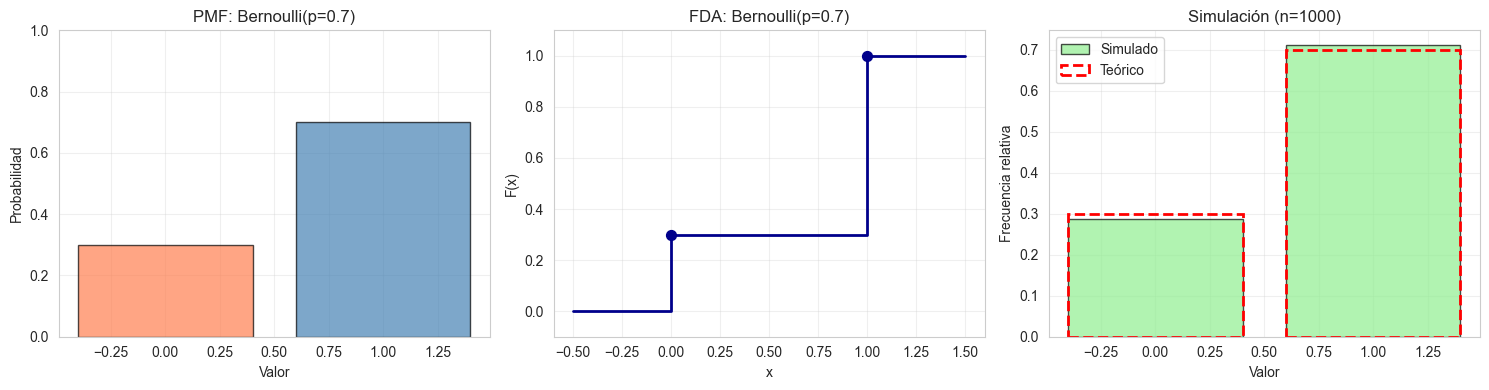

Media teórica: 0.7000
Media empírica: 0.7120
Varianza teórica: 0.2100
Varianza empírica: 0.2053


In [2]:
def plot_bernoulli(p=0.5, n_sim=1000):
    """
    Visualiza la distribución de Bernoulli y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PMF teórica
    x = [0, 1]
    pmf = [1-p, p]
    axes[0].bar(x, pmf, color=['coral', 'steelblue'], alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Valor')
    axes[0].set_ylabel('Probabilidad')
    axes[0].set_title(f'PMF: Bernoulli(p={p})')
    axes[0].set_ylim([0, 1])
    axes[0].grid(True, alpha=0.3)
    
    # FDA teórica
    axes[1].step([-0.5, 0, 1, 1.5], [0, 1-p, 1, 1], where='post', color='darkblue', linewidth=2)
    axes[1].scatter([0, 1], [1-p, 1], color='darkblue', s=50, zorder=3)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Bernoulli(p={p})')
    axes[1].set_ylim([-0.1, 1.1])
    axes[1].grid(True, alpha=0.3)
    
    # Simulación
    samples = np.random.binomial(1, p, n_sim)
    unique, counts = np.unique(samples, return_counts=True)
    freq = counts / n_sim
    axes[2].bar(unique, freq, color='lightgreen', alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].bar(x, pmf, color='none', edgecolor='red', linewidth=2, linestyle='--', label='Teórico')
    axes[2].set_xlabel('Valor')
    axes[2].set_ylabel('Frecuencia relativa')
    axes[2].set_title(f'Simulación (n={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas empíricas
    print(f"Media teórica: {p:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {p*(1-p):.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_bernoulli(p=0.7, n_sim=1000)

### Exploración interactiva: Bernoulli

In [3]:
interact(plot_bernoulli, 
         p=FloatSlider(min=0.1, max=0.9, step=0.1, value=0.5, description='p'),
         n_sim=IntSlider(min=100, max=5000, step=100, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=0.5, description='p', max=0.9, min=0.1), IntSlider(value=1000, descrip…

## 1.2 Distribución Binomial

**Definición:** Número de éxitos en $n$ ensayos de Bernoulli independientes.

$$X \sim \text{Binomial}(n, p)$$

- **Soporte:** $\{0, 1, \ldots, n\}$
- **Parámetros:** $n \in \mathbb{N}$ (número de ensayos), $p \in [0,1]$ (probabilidad de éxito)
- **PMF:** $P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$
- **Media:** $E[X] = np$
- **Varianza:** $\text{Var}(X) = np(1-p)$

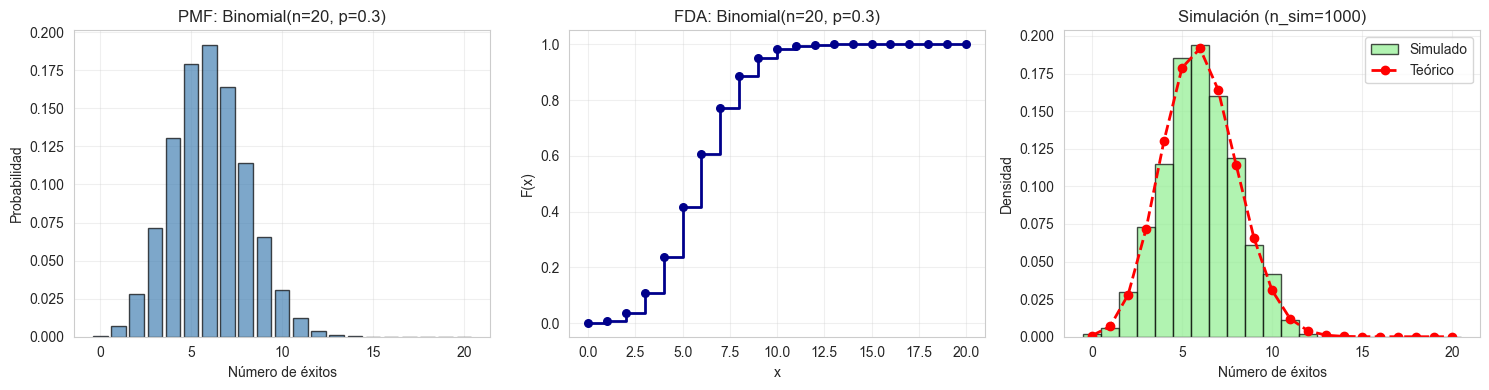

Media teórica: 6.0000
Media empírica: 6.0200
Varianza teórica: 4.2000
Varianza empírica: 4.2118


In [4]:
def plot_binomial(n=10, p=0.5, n_sim=1000):
    """
    Visualiza la distribución Binomial y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PMF teórica
    x = np.arange(0, n+1)
    pmf = stats.binom.pmf(x, n, p)
    axes[0].bar(x, pmf, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Número de éxitos')
    axes[0].set_ylabel('Probabilidad')
    axes[0].set_title(f'PMF: Binomial(n={n}, p={p})')
    axes[0].grid(True, alpha=0.3)
    
    # FDA teórica
    cdf = stats.binom.cdf(x, n, p)
    axes[1].step(x, cdf, where='post', color='darkblue', linewidth=2)
    axes[1].scatter(x, cdf, color='darkblue', s=30, zorder=3)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Binomial(n={n}, p={p})')
    axes[1].grid(True, alpha=0.3)
    
    # Simulación
    samples = np.random.binomial(n, p, n_sim)
    axes[2].hist(samples, bins=np.arange(-0.5, n+1.5, 1), density=True, 
                 color='lightgreen', alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x, pmf, 'ro--', linewidth=2, markersize=6, label='Teórico')
    axes[2].set_xlabel('Número de éxitos')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {n*p:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {n*p*(1-p):.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_binomial(n=20, p=0.3, n_sim=1000)

### Exploración interactiva: Binomial

In [5]:
interact(plot_binomial, 
         n=IntSlider(min=5, max=50, step=5, value=10, description='n'),
         p=FloatSlider(min=0.1, max=0.9, step=0.1, value=0.5, description='p'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(IntSlider(value=10, description='n', max=50, min=5, step=5), FloatSlider(value=0.5, desc…

## 1.3 Distribución de Poisson

**Definición:** Número de eventos que ocurren en un intervalo fijo de tiempo/espacio, cuando los eventos ocurren independientemente a una tasa constante.

$$X \sim \text{Poisson}(\lambda)$$

- **Soporte:** $\{0, 1, 2, \ldots\}$
- **Parámetro:** $\lambda > 0$ (tasa promedio de ocurrencia)
- **PMF:** $P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$
- **Media:** $E[X] = \lambda$
- **Varianza:** $\text{Var}(X) = \lambda$

**Nota:** Poisson es el límite de Binomial$(n, p)$ cuando $n \to \infty$, $p \to 0$, con $np = \lambda$ fijo.

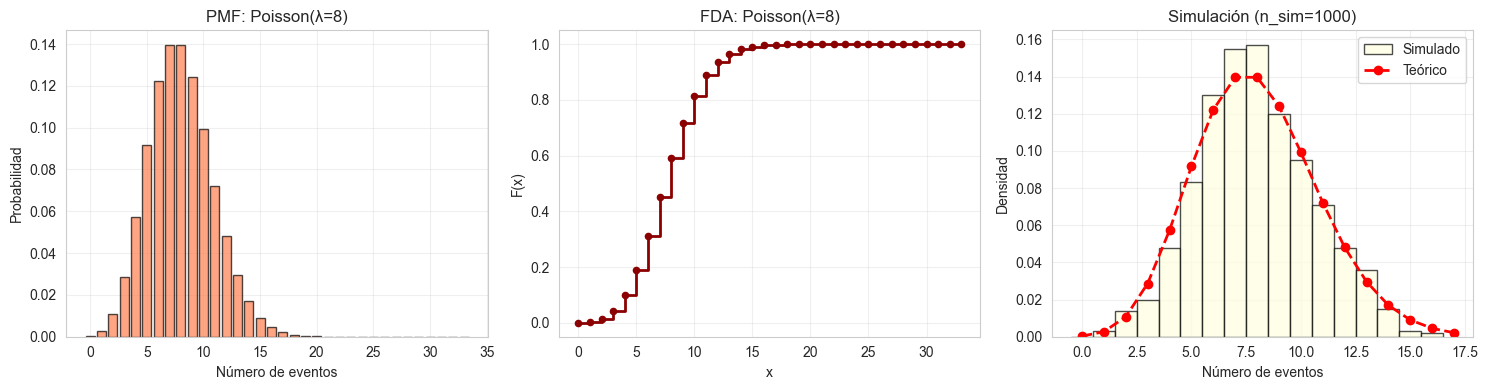

Media teórica: 8.0000
Media empírica: 7.9610
Varianza teórica: 8.0000
Varianza empírica: 6.9684
Razón Var/Media empírica: 0.8753 (≈1 en Poisson)


In [6]:
def plot_poisson(lam=5, n_sim=1000):
    """
    Visualiza la distribución de Poisson y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PMF teórica
    x = np.arange(0, int(lam*3 + 10))
    pmf = stats.poisson.pmf(x, lam)
    axes[0].bar(x, pmf, color='coral', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Número de eventos')
    axes[0].set_ylabel('Probabilidad')
    axes[0].set_title(f'PMF: Poisson(λ={lam})')
    axes[0].grid(True, alpha=0.3)
    
    # FDA teórica
    cdf = stats.poisson.cdf(x, lam)
    axes[1].step(x, cdf, where='post', color='darkred', linewidth=2)
    axes[1].scatter(x, cdf, color='darkred', s=20, zorder=3)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Poisson(λ={lam})')
    axes[1].grid(True, alpha=0.3)
    
    # Simulación
    samples = np.random.poisson(lam, n_sim)
    axes[2].hist(samples, bins=np.arange(-0.5, max(samples)+1.5, 1), density=True,
                 color='lightyellow', alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x[x <= max(samples)+1], pmf[x <= max(samples)+1], 'ro--', 
                 linewidth=2, markersize=6, label='Teórico')
    axes[2].set_xlabel('Número de eventos')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {lam:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {lam:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")
    print(f"Razón Var/Media empírica: {np.var(samples, ddof=1)/np.mean(samples):.4f} (≈1 en Poisson)")

# Ejemplo
plot_poisson(lam=8, n_sim=1000)

### Exploración interactiva: Poisson

In [ ]:
interact(plot_poisson, 
         lam=FloatSlider(min=0.5, max=20, step=0.5, value=5, description='λ'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=5.0, description='λ', max=20.0, min=0.5, step=0.5), IntSlider(value=10…

### Relación Binomial-Poisson

Vamos a verificar empíricamente que Poisson es el límite de la Binomial cuando $n \to \infty$, $p \to 0$, con $\lambda = np$ fijo.

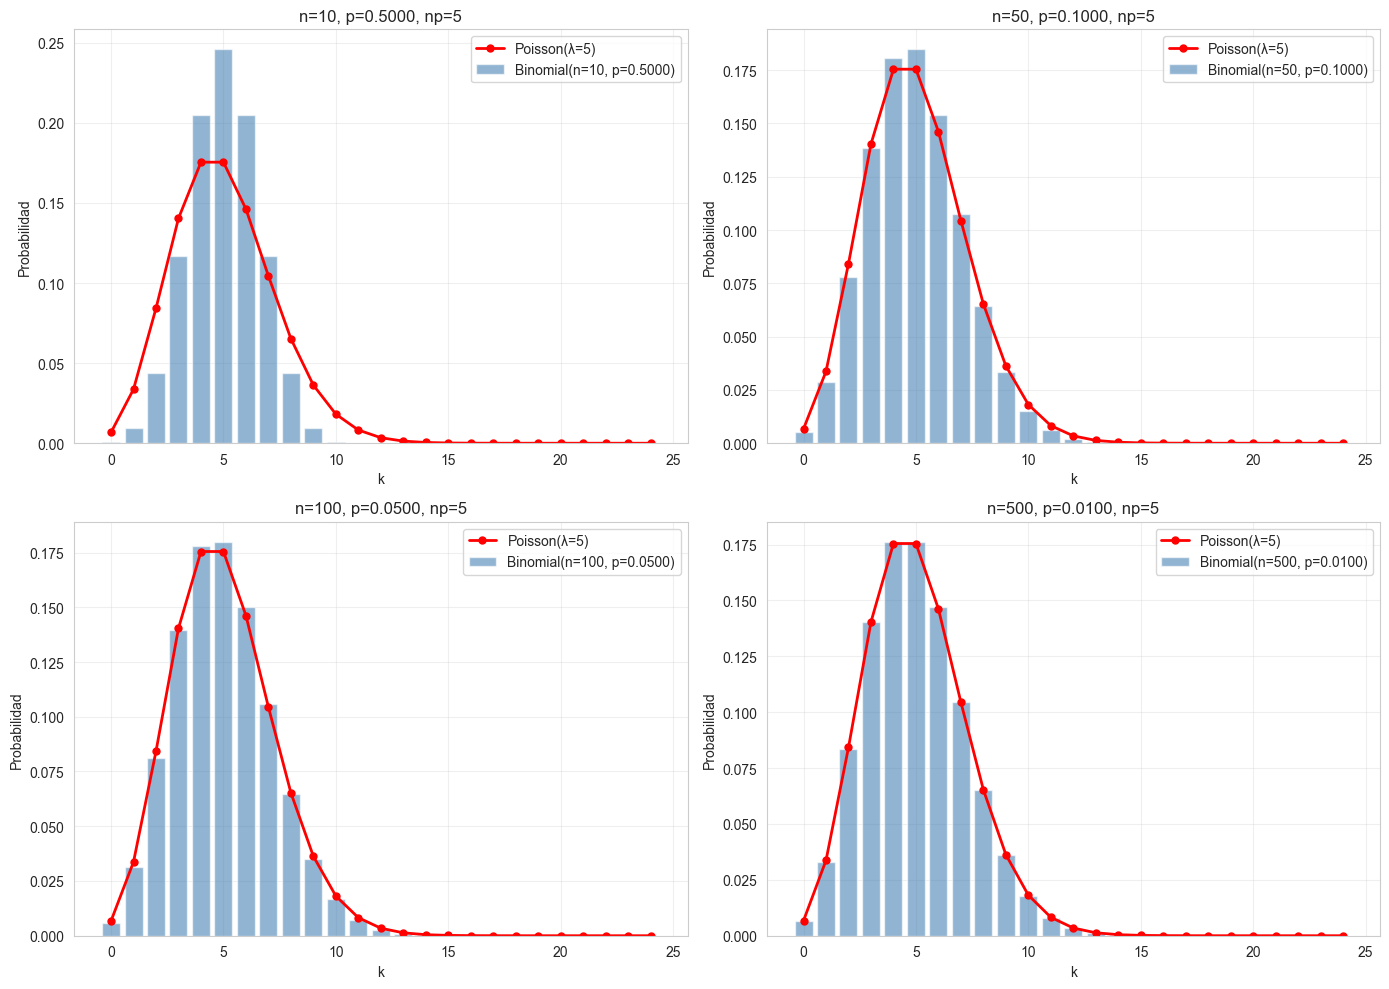

A medida que n aumenta y p → 0 (con np = 5 fijo), 
la Binomial converge a la Poisson.


In [8]:
def compare_binomial_poisson(lam=5):
    """
    Compara Binomial(n, p) con Poisson(λ) para n grande y p pequeño.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    n_values = [10, 50, 100, 500]
    
    for idx, n in enumerate(n_values):
        p = lam / n
        x = np.arange(0, int(lam*3 + 10))
        
        # PMF Binomial y Poisson
        pmf_binom = stats.binom.pmf(x, n, p)
        pmf_poisson = stats.poisson.pmf(x, lam)
        
        axes[idx].bar(x, pmf_binom, alpha=0.6, label=f'Binomial(n={n}, p={p:.4f})', color='steelblue')
        axes[idx].plot(x, pmf_poisson, 'ro-', linewidth=2, markersize=5, label=f'Poisson(λ={lam})')
        axes[idx].set_xlabel('k')
        axes[idx].set_ylabel('Probabilidad')
        axes[idx].set_title(f'n={n}, p={p:.4f}, np={lam}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print(f"A medida que n aumenta y p → 0 (con np = {lam} fijo), ")
    print(f"la Binomial converge a la Poisson.")

compare_binomial_poisson(lam=5)

## 1.4 Distribución Geométrica

**Definición:** Número de ensayos de Bernoulli necesarios hasta obtener el primer éxito.

$$X \sim \text{Geométrica}(p)$$

- **Soporte:** $\{1, 2, 3, \ldots\}$
- **Parámetro:** $p \in (0,1]$ (probabilidad de éxito)
- **PMF:** $P(X = k) = (1-p)^{k-1} p$
- **Media:** $E[X] = \frac{1}{p}$
- **Varianza:** $\text{Var}(X) = \frac{1-p}{p^2}$

**Propiedad de falta de memoria:** $P(X > n+m \mid X > n) = P(X > m)$

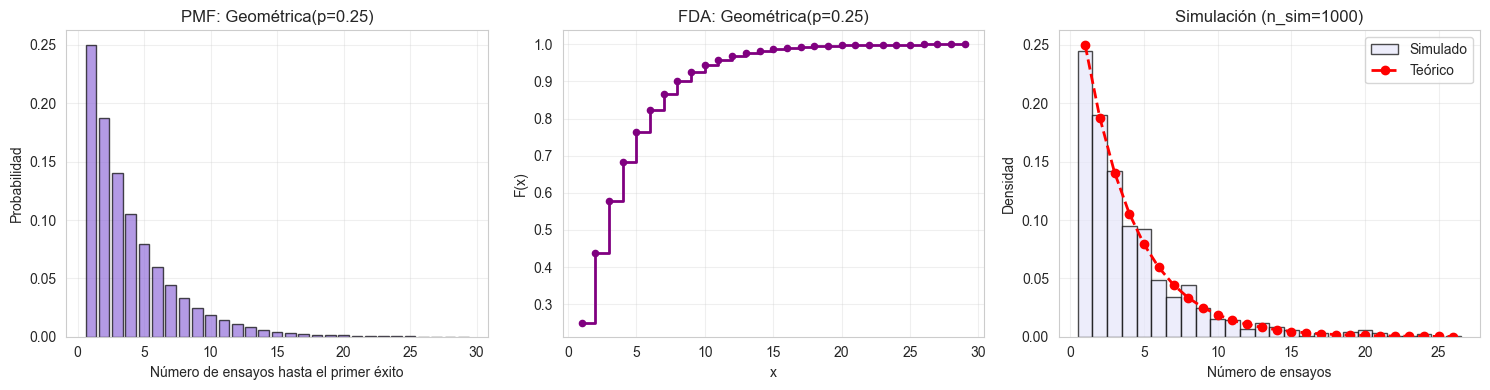

Media teórica: 4.0000
Media empírica: 4.1910
Varianza teórica: 12.0000
Varianza empírica: 15.1036


In [9]:
def plot_geometric(p=0.3, n_sim=1000):
    """
    Visualiza la distribución Geométrica y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PMF teórica
    x = np.arange(1, int(5/p) + 10)
    pmf = stats.geom.pmf(x, p)
    axes[0].bar(x, pmf, color='mediumpurple', alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Número de ensayos hasta el primer éxito')
    axes[0].set_ylabel('Probabilidad')
    axes[0].set_title(f'PMF: Geométrica(p={p})')
    axes[0].grid(True, alpha=0.3)
    
    # FDA teórica
    cdf = stats.geom.cdf(x, p)
    axes[1].step(x, cdf, where='post', color='purple', linewidth=2)
    axes[1].scatter(x, cdf, color='purple', s=20, zorder=3)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Geométrica(p={p})')
    axes[1].grid(True, alpha=0.3)
    
    # Simulación
    samples = np.random.geometric(p, n_sim)
    max_val = min(max(samples), int(5/p) + 20)
    axes[2].hist(samples, bins=np.arange(0.5, max_val+1.5, 1), density=True,
                 color='lavender', alpha=0.7, edgecolor='black', label='Simulado')
    x_plot = x[x <= max_val]
    axes[2].plot(x_plot, stats.geom.pmf(x_plot, p), 'ro--', 
                 linewidth=2, markersize=6, label='Teórico')
    axes[2].set_xlabel('Número de ensayos')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {1/p:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {(1-p)/p**2:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_geometric(p=0.25, n_sim=1000)

### Exploración interactiva: Geométrica

In [10]:
interact(plot_geometric, 
         p=FloatSlider(min=0.05, max=0.95, step=0.05, value=0.3, description='p'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=0.3, description='p', max=0.95, min=0.05, step=0.05), IntSlider(value=…

---

# Parte II: Distribuciones Continuas

## 2.1 Distribución Uniforme Continua

**Definición:** Todos los valores en un intervalo $[a, b]$ son igualmente probables.

$$X \sim \text{Uniforme}(a, b)$$

- **Soporte:** $[a, b]$
- **Parámetros:** $a, b \in \mathbb{R}$ con $a < b$
- **PDF:** $f(x) = \frac{1}{b-a}$ para $x \in [a,b]$, y $0$ en otro caso
- **FDA:** $F(x) = \begin{cases} 0 & x < a \\ \frac{x-a}{b-a} & a \leq x \leq b \\ 1 & x > b \end{cases}$
- **Media:** $E[X] = \frac{a+b}{2}$
- **Varianza:** $\text{Var}(X) = \frac{(b-a)^2}{12}$

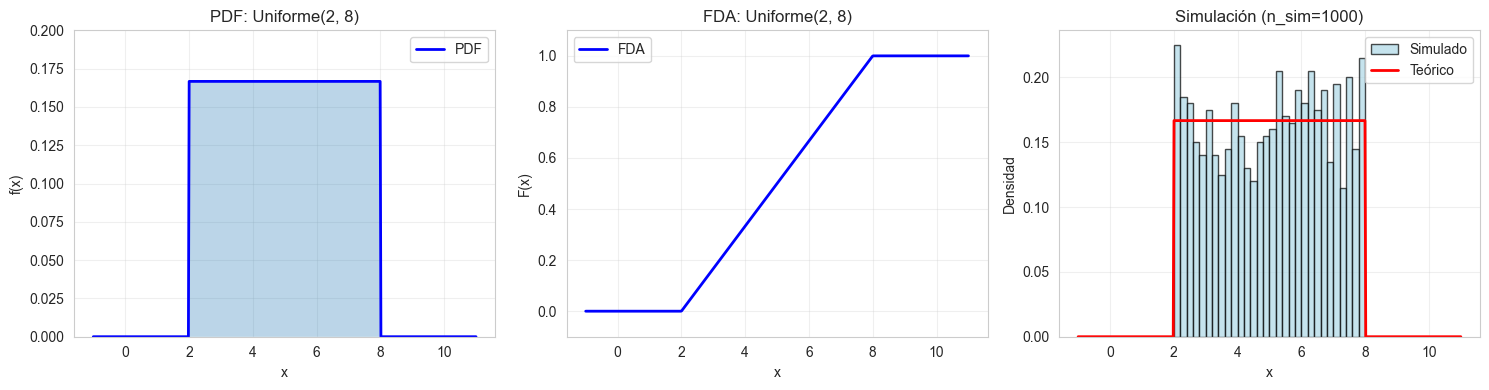

Media teórica: 5.0000
Media empírica: 5.0433
Varianza teórica: 3.0000
Varianza empírica: 3.1305


In [11]:
def plot_uniform(a=0, b=1, n_sim=1000):
    """
    Visualiza la distribución Uniforme continua y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PDF teórica
    x = np.linspace(a - (b-a)*0.5, b + (b-a)*0.5, 500)
    pdf = stats.uniform.pdf(x, loc=a, scale=b-a)
    axes[0].plot(x, pdf, 'b-', linewidth=2, label='PDF')
    axes[0].fill_between(x, pdf, alpha=0.3)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title(f'PDF: Uniforme({a}, {b})')
    axes[0].set_ylim([0, 1.2/(b-a)])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # FDA teórica
    cdf = stats.uniform.cdf(x, loc=a, scale=b-a)
    axes[1].plot(x, cdf, 'b-', linewidth=2, label='FDA')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Uniforme({a}, {b})')
    axes[1].set_ylim([-0.1, 1.1])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Simulación
    samples = np.random.uniform(a, b, n_sim)
    axes[2].hist(samples, bins=30, density=True, color='lightblue', 
                 alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x, pdf, 'r-', linewidth=2, label='Teórico')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {(a+b)/2:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {(b-a)**2/12:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_uniform(a=2, b=8, n_sim=1000)

### Exploración interactiva: Uniforme

In [12]:
interact(plot_uniform, 
         a=FloatSlider(min=-5, max=5, step=0.5, value=0, description='a'),
         b=FloatSlider(min=-5, max=10, step=0.5, value=1, description='b'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=0.0, description='a', max=5.0, min=-5.0, step=0.5), FloatSlider(value=…

## 2.2 Distribución Exponencial

**Definición:** Tiempo de espera hasta que ocurre el primer evento en un proceso de Poisson.

$$X \sim \text{Exponencial}(\lambda)$$

- **Soporte:** $[0, \infty)$
- **Parámetro:** $\lambda > 0$ (tasa)
- **PDF:** $f(x) = \lambda e^{-\lambda x}$ para $x \geq 0$
- **FDA:** $F(x) = 1 - e^{-\lambda x}$ para $x \geq 0$
- **Media:** $E[X] = \frac{1}{\lambda}$
- **Varianza:** $\text{Var}(X) = \frac{1}{\lambda^2}$

**Propiedad de falta de memoria:** $P(X > s+t \mid X > s) = P(X > t)$

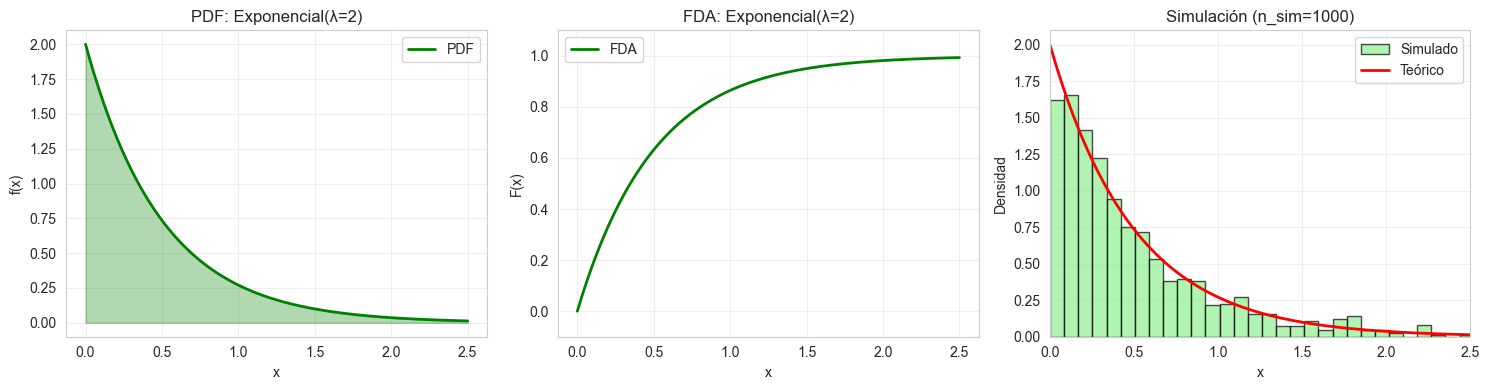

Media teórica: 0.5000
Media empírica: 0.5063
Varianza teórica: 0.2500
Varianza empírica: 0.2537


In [13]:
def plot_exponential(lam=1, n_sim=1000):
    """
    Visualiza la distribución Exponencial y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PDF teórica
    x = np.linspace(0, 5/lam, 500)
    pdf = stats.expon.pdf(x, scale=1/lam)
    axes[0].plot(x, pdf, 'g-', linewidth=2, label='PDF')
    axes[0].fill_between(x, pdf, alpha=0.3, color='green')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title(f'PDF: Exponencial(λ={lam})')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # FDA teórica
    cdf = stats.expon.cdf(x, scale=1/lam)
    axes[1].plot(x, cdf, 'g-', linewidth=2, label='FDA')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Exponencial(λ={lam})')
    axes[1].set_ylim([-0.1, 1.1])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Simulación
    samples = np.random.exponential(1/lam, n_sim)
    axes[2].hist(samples, bins=40, density=True, color='lightgreen', 
                 alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x, pdf, 'r-', linewidth=2, label='Teórico')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].set_xlim([0, 5/lam])
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {1/lam:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {1/lam**2:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_exponential(lam=2, n_sim=1000)

### Exploración interactiva: Exponencial

In [ ]:
interact(plot_exponential, 
         lam=FloatSlider(min=0.1, max=5, step=0.1, value=1, description='λ'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=1.0, description='λ', max=5.0, min=0.1), IntSlider(value=1000, descrip…

## 2.3 Distribución Normal (Gaussiana)

**Definición:** La distribución continua más importante en estadística. Aparece naturalmente en muchos fenómenos debido al Teorema Central del Límite.

$$X \sim \mathcal{N}(\mu, \sigma^2)$$

- **Soporte:** $(-\infty, \infty)$
- **Parámetros:** $\mu \in \mathbb{R}$ (media), $\sigma^2 > 0$ (varianza)
- **PDF:** $f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$
- **Media:** $E[X] = \mu$
- **Varianza:** $\text{Var}(X) = \sigma^2$

**Normal estándar:** $Z \sim \mathcal{N}(0, 1)$ cuando $\mu=0, \sigma=1$

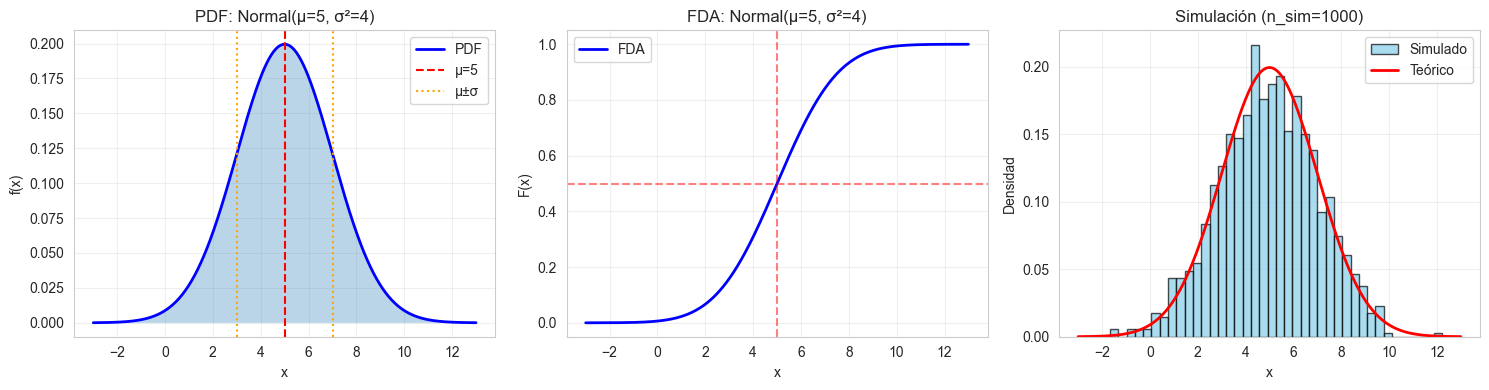

Media teórica: 5.0000
Media empírica: 4.9472
Varianza teórica: 4.0000
Varianza empírica: 4.1644

Regla empírica (68-95-99.7):
  P(μ-σ < X < μ+σ) ≈ 0.667 (esperado: 0.683)
  P(μ-2σ < X < μ+2σ) ≈ 0.948 (esperado: 0.954)


In [15]:
def plot_normal(mu=0, sigma=1, n_sim=1000):
    """
    Visualiza la distribución Normal y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PDF teórica
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
    pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
    axes[0].plot(x, pdf, 'b-', linewidth=2, label='PDF')
    axes[0].fill_between(x, pdf, alpha=0.3)
    axes[0].axvline(mu, color='red', linestyle='--', linewidth=1.5, label=f'μ={mu}')
    axes[0].axvline(mu-sigma, color='orange', linestyle=':', linewidth=1.5, label=f'μ±σ')
    axes[0].axvline(mu+sigma, color='orange', linestyle=':', linewidth=1.5)
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title(f'PDF: Normal(μ={mu}, σ²={sigma**2})')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # FDA teórica
    cdf = stats.norm.cdf(x, loc=mu, scale=sigma)
    axes[1].plot(x, cdf, 'b-', linewidth=2, label='FDA')
    axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    axes[1].axvline(mu, color='red', linestyle='--', linewidth=1.5, alpha=0.5)
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Normal(μ={mu}, σ²={sigma**2})')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Simulación
    samples = np.random.normal(mu, sigma, n_sim)
    axes[2].hist(samples, bins=40, density=True, color='skyblue', 
                 alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x, pdf, 'r-', linewidth=2, label='Teórico')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {mu:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {sigma**2:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")
    print(f"\nRegla empírica (68-95-99.7):")
    print(f"  P(μ-σ < X < μ+σ) ≈ {np.sum((samples > mu-sigma) & (samples < mu+sigma))/n_sim:.3f} (esperado: 0.683)")
    print(f"  P(μ-2σ < X < μ+2σ) ≈ {np.sum((samples > mu-2*sigma) & (samples < mu+2*sigma))/n_sim:.3f} (esperado: 0.954)")

# Ejemplo
plot_normal(mu=5, sigma=2, n_sim=1000)

### Exploración interactiva: Normal

In [16]:
interact(plot_normal, 
         mu=FloatSlider(min=-5, max=5, step=0.5, value=0, description='μ'),
         sigma=FloatSlider(min=0.5, max=5, step=0.5, value=1, description='σ'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=0.0, description='μ', max=5.0, min=-5.0, step=0.5), FloatSlider(value=…

### Comparación de Normales con diferentes parámetros

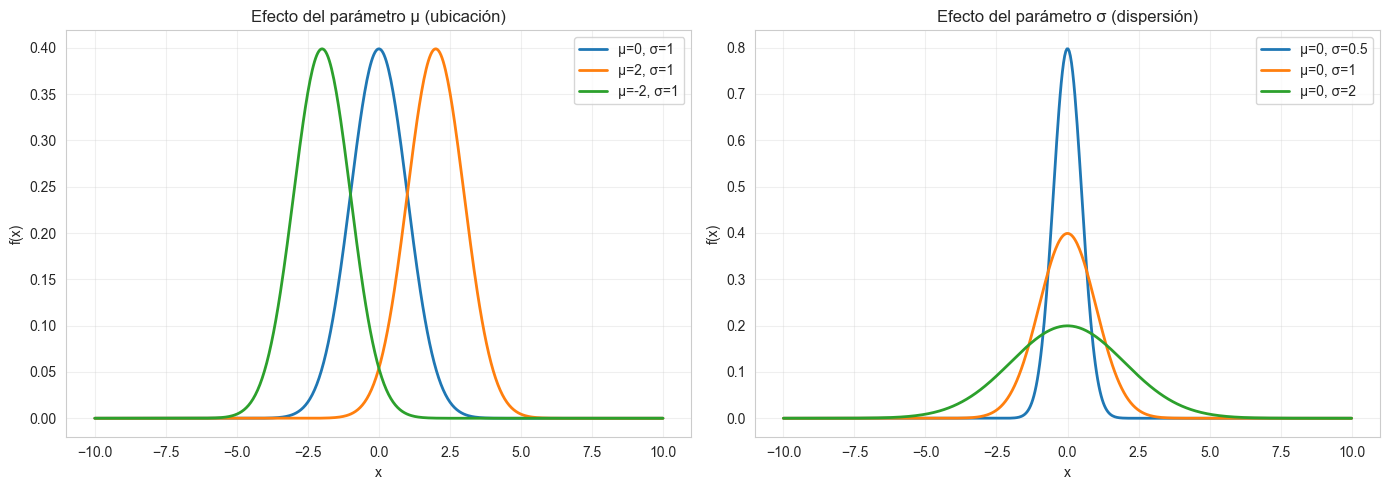

In [17]:
def compare_normals():
    """
    Compara varias distribuciones Normales en un mismo gráfico.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    x = np.linspace(-10, 10, 500)
    
    # Efecto de μ (media)
    for mu in [0, 2, -2]:
        pdf = stats.norm.pdf(x, loc=mu, scale=1)
        axes[0].plot(x, pdf, linewidth=2, label=f'μ={mu}, σ=1')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title('Efecto del parámetro μ (ubicación)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Efecto de σ (desviación estándar)
    for sigma in [0.5, 1, 2]:
        pdf = stats.norm.pdf(x, loc=0, scale=sigma)
        axes[1].plot(x, pdf, linewidth=2, label=f'μ=0, σ={sigma}')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('f(x)')
    axes[1].set_title('Efecto del parámetro σ (dispersión)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

compare_normals()

## 2.4 Distribución Gamma

**Definición:** Generalización de la Exponencial. Tiempo de espera hasta que ocurren $k$ eventos en un proceso de Poisson.

$$X \sim \text{Gamma}(\alpha, \beta)$$

- **Soporte:** $(0, \infty)$
- **Parámetros:** $\alpha > 0$ (forma/shape), $\beta > 0$ (tasa/rate)
- **PDF:** $f(x) = \frac{\beta^\alpha}{\Gamma(\alpha)} x^{\alpha-1} e^{-\beta x}$ para $x > 0$
- **Media:** $E[X] = \frac{\alpha}{\beta}$
- **Varianza:** $\text{Var}(X) = \frac{\alpha}{\beta^2}$

**Casos especiales:**
- $\alpha = 1$: Exponencial($\beta$)
- $\alpha = \frac{n}{2}, \beta = \frac{1}{2}$: Chi-cuadrado con $n$ grados de libertad

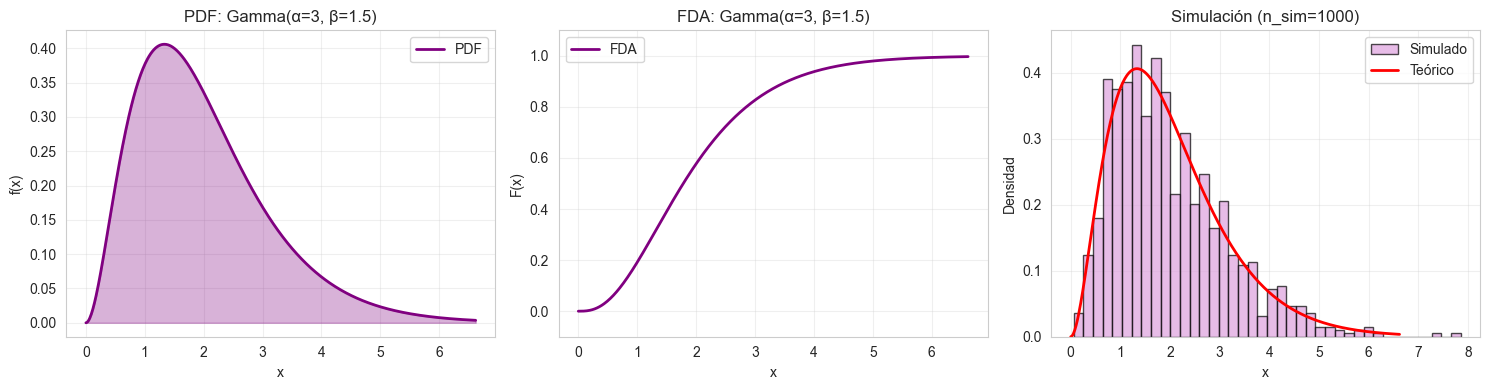

Media teórica: 2.0000
Media empírica: 1.9855
Varianza teórica: 1.3333
Varianza empírica: 1.3190


In [18]:
def plot_gamma(alpha=2, beta=1, n_sim=1000):
    """
    Visualiza la distribución Gamma y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PDF teórica
    x = np.linspace(0.001, alpha/beta + 4*np.sqrt(alpha/beta**2), 500)
    pdf = stats.gamma.pdf(x, a=alpha, scale=1/beta)
    axes[0].plot(x, pdf, 'purple', linewidth=2, label='PDF')
    axes[0].fill_between(x, pdf, alpha=0.3, color='purple')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title(f'PDF: Gamma(α={alpha}, β={beta})')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # FDA teórica
    cdf = stats.gamma.cdf(x, a=alpha, scale=1/beta)
    axes[1].plot(x, cdf, 'purple', linewidth=2, label='FDA')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Gamma(α={alpha}, β={beta})')
    axes[1].set_ylim([-0.1, 1.1])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Simulación
    samples = np.random.gamma(alpha, 1/beta, n_sim)
    axes[2].hist(samples, bins=40, density=True, color='plum', 
                 alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x, pdf, 'r-', linewidth=2, label='Teórico')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {alpha/beta:.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    print(f"Varianza teórica: {alpha/beta**2:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_gamma(alpha=3, beta=1.5, n_sim=1000)

### Exploración interactiva: Gamma

In [19]:
interact(plot_gamma, 
         alpha=FloatSlider(min=0.5, max=10, step=0.5, value=2, description='α'),
         beta=FloatSlider(min=0.5, max=5, step=0.5, value=1, description='β'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=2.0, description='α', max=10.0, min=0.5, step=0.5), FloatSlider(value=…

## 2.5 Distribución Beta

**Definición:** Distribución sobre el intervalo $[0,1]$, útil para modelar proporciones y probabilidades.

$$X \sim \text{Beta}(\alpha, \beta)$$

- **Soporte:** $[0, 1]$
- **Parámetros:** $\alpha > 0$, $\beta > 0$ (parámetros de forma)
- **PDF:** $f(x) = \frac{\Gamma(\alpha + \beta)}{\Gamma(\alpha)\Gamma(\beta)} x^{\alpha-1}(1-x)^{\beta-1}$ para $x \in [0,1]$
- **Media:** $E[X] = \frac{\alpha}{\alpha + \beta}$
- **Varianza:** $\text{Var}(X) = \frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$

**Formas especiales:**
- $\alpha = \beta = 1$: Uniforme(0,1)
- $\alpha = \beta$: simétrica respecto a 0.5
- $\alpha < 1, \beta < 1$: forma de U
- $\alpha > 1, \beta > 1$: forma de campana

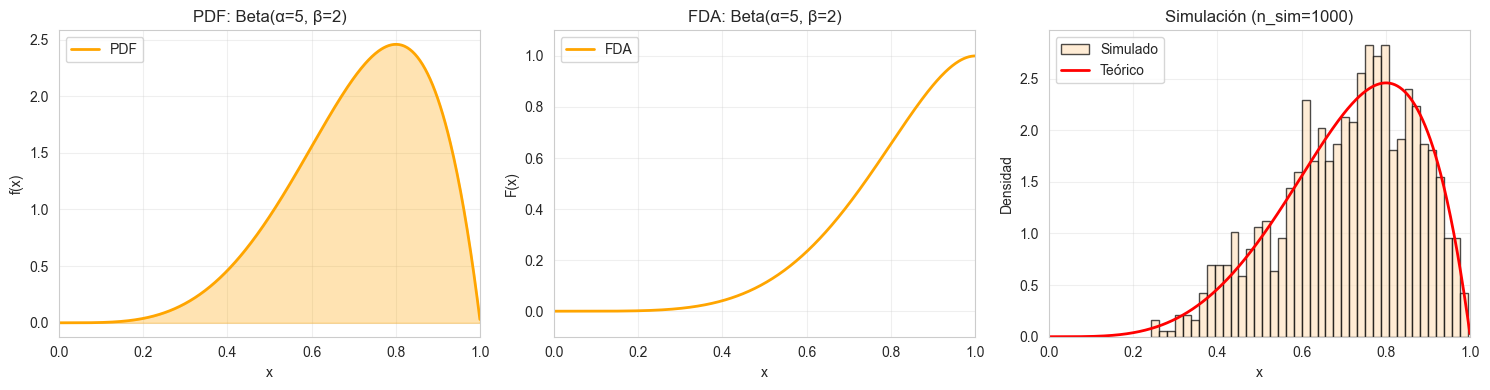

Media teórica: 0.7143
Media empírica: 0.7095
Varianza teórica: 0.0255
Varianza empírica: 0.0250


In [20]:
def plot_beta(alpha=2, beta=2, n_sim=1000):
    """
    Visualiza la distribución Beta y simulaciones.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # PDF teórica
    x = np.linspace(0.001, 0.999, 500)
    pdf = stats.beta.pdf(x, a=alpha, b=beta)
    axes[0].plot(x, pdf, 'orange', linewidth=2, label='PDF')
    axes[0].fill_between(x, pdf, alpha=0.3, color='orange')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('f(x)')
    axes[0].set_title(f'PDF: Beta(α={alpha}, β={beta})')
    axes[0].set_xlim([0, 1])
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    
    # FDA teórica
    cdf = stats.beta.cdf(x, a=alpha, b=beta)
    axes[1].plot(x, cdf, 'orange', linewidth=2, label='FDA')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('F(x)')
    axes[1].set_title(f'FDA: Beta(α={alpha}, β={beta})')
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([-0.1, 1.1])
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    
    # Simulación
    samples = np.random.beta(alpha, beta, n_sim)
    axes[2].hist(samples, bins=40, density=True, color='bisque', 
                 alpha=0.7, edgecolor='black', label='Simulado')
    axes[2].plot(x, pdf, 'r-', linewidth=2, label='Teórico')
    axes[2].set_xlabel('x')
    axes[2].set_ylabel('Densidad')
    axes[2].set_title(f'Simulación (n_sim={n_sim})')
    axes[2].set_xlim([0, 1])
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Estadísticas
    print(f"Media teórica: {alpha/(alpha+beta):.4f}")
    print(f"Media empírica: {np.mean(samples):.4f}")
    var_teo = (alpha*beta) / ((alpha+beta)**2 * (alpha+beta+1))
    print(f"Varianza teórica: {var_teo:.4f}")
    print(f"Varianza empírica: {np.var(samples, ddof=1):.4f}")

# Ejemplo
plot_beta(alpha=5, beta=2, n_sim=1000)

### Exploración interactiva: Beta

In [21]:
interact(plot_beta, 
         alpha=FloatSlider(min=0.5, max=10, step=0.5, value=2, description='α'),
         beta=FloatSlider(min=0.5, max=10, step=0.5, value=2, description='β'),
         n_sim=IntSlider(min=500, max=5000, step=500, value=1000, description='n_sim'));

interactive(children=(FloatSlider(value=2.0, description='α', max=10.0, min=0.5, step=0.5), FloatSlider(value=…

### Formas especiales de la distribución Beta

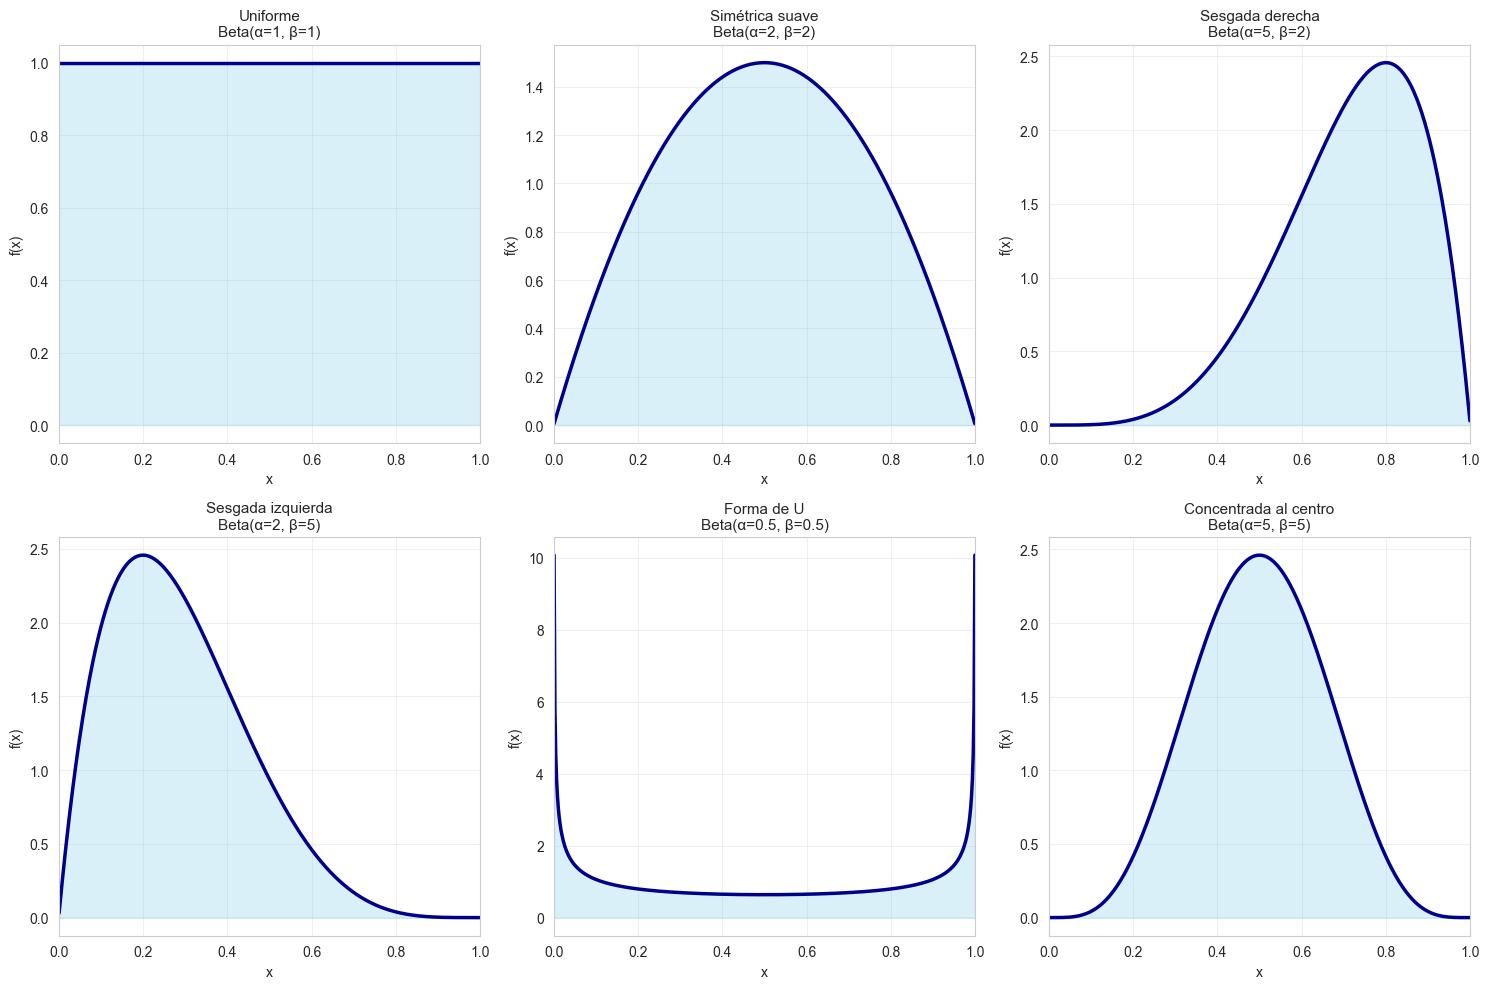

In [22]:
def show_beta_shapes():
    """
    Muestra diferentes formas que puede tomar la distribución Beta.
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    params = [(1, 1), (2, 2), (5, 2), (2, 5), (0.5, 0.5), (5, 5)]
    titles = ['Uniforme', 'Simétrica suave', 'Sesgada derecha', 
              'Sesgada izquierda', 'Forma de U', 'Concentrada al centro']
    
    x = np.linspace(0.001, 0.999, 500)
    
    for idx, (alpha, beta) in enumerate(params):
        pdf = stats.beta.pdf(x, a=alpha, b=beta)
        axes[idx].plot(x, pdf, linewidth=2.5, color='darkblue')
        axes[idx].fill_between(x, pdf, alpha=0.3, color='skyblue')
        axes[idx].set_title(f'{titles[idx]}\nBeta(α={alpha}, β={beta})', fontsize=11)
        axes[idx].set_xlabel('x')
        axes[idx].set_ylabel('f(x)')
        axes[idx].set_xlim([0, 1])
        axes[idx].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

show_beta_shapes()

---

# Ejercicios Propuestos

## Ejercicio 1: Verificación de propiedades

Para una distribución de tu elección:

a) Genera 10,000 muestras y verifica que la media empírica se aproxima a la teórica.  
b) Verifica que la varianza empírica se aproxima a la teórica.  
c) Grafica el histograma normalizado junto con la PDF/PMF teórica.  
d) Calcula cuartiles empíricos y compáralos con los teóricos.

## Ejercicio 2: Teorema Central del Límite

a) Genera 1,000 muestras de tamaño $n=30$ de una distribución Exponencial($\lambda=2$).  
b) Calcula la media de cada muestra.  
c) Grafica el histograma de estas medias y superpone una Normal con media $1/\lambda$ y varianza $1/(n\lambda^2)$.  
d) Repite con $n=5$ y $n=100$. ¿Qué observas?

## Ejercicio 3: Simulación de procesos

a) Simula el número de llamadas que llegan a un call center en una hora, si la tasa promedio es 15 llamadas/hora (usa Poisson).  
b) Para cada llamada, simula el tiempo de servicio usando una Exponencial con media 3 minutos.  
c) Calcula el tiempo total de servicio en la hora.  
d) Repite la simulación 1,000 veces y grafica la distribución del tiempo total.

## Ejercicio 4: Estimación de parámetros

Se te proporciona una muestra de datos. Identifica qué distribución podría ajustar bien y estima sus parámetros usando el método de los momentos (igualar media y varianza muestral con las teóricas).

Muestra de datos:
[ 3.91191711 11.85438423  5.33315539 15.65024281  1.41290797  5.81031468
  5.02855113  6.97657259  5.76103967  5.79249865 11.88980613  8.9139693
  4.30151423 12.82101902 11.38471541  3.10984817  6.3973004   0.98904726
 11.48956341  6.68825635]

Media muestral: 8.1111
Varianza muestral: 15.6376


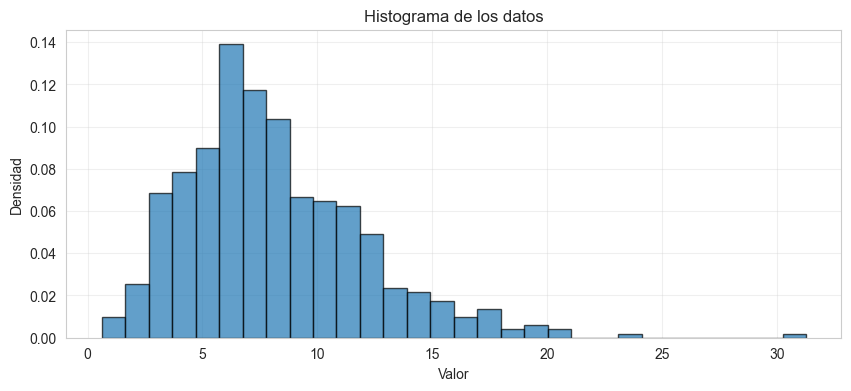

In [23]:
# Datos para el Ejercicio 4
np.random.seed(123)
datos_misterio = np.random.gamma(shape=4, scale=2, size=500)

print("Muestra de datos:")
print(datos_misterio[:20])
print(f"\nMedia muestral: {np.mean(datos_misterio):.4f}")
print(f"Varianza muestral: {np.var(datos_misterio, ddof=1):.4f}")

plt.figure(figsize=(10, 4))
plt.hist(datos_misterio, bins=30, density=True, alpha=0.7, edgecolor='black')
plt.xlabel('Valor')
plt.ylabel('Densidad')
plt.title('Histograma de los datos')
plt.grid(True, alpha=0.3)
plt.show()

# Tu tarea: ¿Qué distribución es? ¿Cuáles son los parámetros estimados?

## Ejercicio 5: Relación entre distribuciones

a) Genera muestras de una Gamma(3, 2) y verifica que la suma de 3 Exponenciales(2) tiene la misma distribución.  
b) Verifica que si $X \sim \text{Binomial}(n, p)$ con $n$ grande y $p$ pequeño, entonces $X$ se aproxima a una Poisson($\lambda = np$).

---

## Recursos adicionales

- **Documentación de scipy.stats:** https://docs.scipy.org/doc/scipy/reference/stats.html
- **Visualización interactiva de distribuciones:** https://seeing-theory.brown.edu/
- **Libro recomendado:** Casella & Berger - *Statistical Inference*

---

**Próxima clase:** Clasificación de variables aleatorias, Integral de Riemann-Stieltjes, y Momentos.